## Support Vector Machines (SVMs): The Primal Optimization Problem

In this notebook, we will optimize the SVMs primal objective with stochastic subgradient descent.

Check out the [blog post](https://github.com/didarulilm/ml-notebooks) where I explained how to derive the optimization problem from scratch.


In [354]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [355]:
data = pd.read_csv("../data/non_separable_data.csv")
data

,Feature 1,Feature 2,Label
0,3.764052,2.400157,0.0
1,0.729515,2.969397,0.0
2,0.826877,3.943621,0.0
3,1.586381,1.252545,0.0
4,3.922942,3.480515,0.0
...,...,...,...
295,-0.647181,0.472247,1.0
296,0.930408,-0.175316,1.0
297,-1.421920,1.997956,1.0
298,-0.856549,-1.541587,1.0


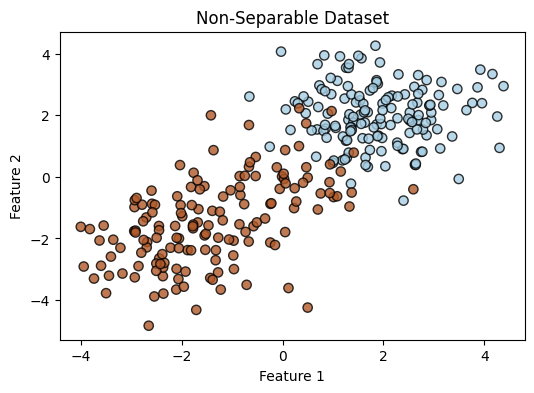

In [356]:
features = data.drop("Label", axis=1).values
labels = data["Label"].values
transformed_labels = np.where(labels == 1, 1, -1)

# Plot the dataset
plt.figure(figsize=(6, 4))
plt.scatter(
    features[:, 0],
    features[:, 1],
    c=(transformed_labels == 1).astype(int),
    cmap="Paired",
    edgecolors="k",
    s=45,
    alpha=0.8,
)
plt.title("Non-Separable Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Split the dataset into training and test set
features_train, features_test, labels_train, labels_test = train_test_split(
    features, transformed_labels, test_size=0.2, random_state=42
)

### Cost Function, Subgradient, and Inference

Recall that the primal SVM cost function $J(w,b)$ is defined as

$$
J(w,b)={\frac{\lambda}{2}||w||^2} + \frac{1}{M}\sum_{i=1}^{M} \max(0, 1 - y_i(w^Tx_i+b))
$$

where $\lambda>0$ is the regularization parameter.

The subgradient of the cost function with respect to $w$ is given by

$$
{\nabla}_{w}J(w,b) = \lambda w + \frac{1}{M}\sum_{i=1}^{M}\begin{cases}
-  y_ix_i&\quad \text{if } y_i(w^Tx_i+b) < 1\\
0 &\quad \text{otherwise}
\end{cases}
$$

and the subgradient with respect to $b$ is given by

$$
\frac{\partial}{\partial b}J(w,b)=\frac{1}{M}\sum_{i=1}^{M}\begin{cases}
-  y_i&\quad \text{if } y_i(w^Tx_i+b) < 1\\
0 &\quad \text{otherwise}
\end{cases}
$$

After training, we can evaluate the model on unseen data. The predicted label $\hat y$ for a test instance $x_{test}$ is simply:
$$\hat y ​=sign(w^Tx_{test}+b​)$$


In [357]:
class PrimalSVM:
    def __init__(self, regularization_param):
        """
        Initialize the primal SVM model.
        """
        self.regularization_param = regularization_param
        self.weights = None
        self.bias = 0.0

    def _compute_cost(self, features, labels) -> float:
        """
        Compute the scalar value of the cost function.
        """
        n_samples = features.shape[0]

        if self.weights is None:
            raise ValueError("Model not trained: call fit() to set weights first.")

        # Compute the loss term
        scores = np.dot(features, self.weights) + self.bias
        y_scores = labels * scores
        hinge_loss = np.maximum(0, 1 - y_scores)
        loss_term = np.sum(hinge_loss) / n_samples

        # Compute the overall cost
        regularizer = 0.5 * self.regularization_param * np.dot(self.weights, self.weights)
        cost = regularizer + loss_term

        return float(cost)

    def _compute_subgradient(self, features, labels) -> tuple[np.ndarray, float]:
        """
        Compute the subgradient of the cost function with respect to weights and bias.
        """
        n_samples = features.shape[0]

        if self.weights is None:
            raise ValueError("Model not trained: call fit() to set weights first.")

        scores = np.dot(features, self.weights) + self.bias
        y_scores = labels * scores
        violations = y_scores < 1

        # Compute subgradients of the regularizer term
        subgrad_w = self.regularization_param * self.weights
        subgrad_b = 0.0

        # Add subgradients of the loss term
        if np.any(violations):
            subgrad_w -= np.dot(features[violations].T, labels[violations]) / n_samples
            subgrad_b -= np.sum(labels[violations]) / n_samples

        return subgrad_w, subgrad_b

    def fit(self, features, labels, epochs=100, learning_rate=0.001, batch_size=1, tol=1e-6):
        """
        Train the model with stochastic subgradient descent with support for mini-batches.
        """        
        # Initialize weight vectors to zeros
        n_samples, n_features = features.shape
        self.weights = np.zeros(n_features, dtype=float)

        # Set the seed for reproducibility
        rng = np.random.default_rng(seed=42)

        prev_cost = None

        # Each epoch is one full pass over the dataset
        for epoch in range(epochs):
            indices = rng.permutation(n_samples)
            features = features[indices]
            labels = labels[indices]

            # Iterate over mini-batches
            for idx in range(0, n_samples, batch_size):
                features_batch = features[idx:idx + batch_size]
                labels_batch = labels[idx:idx + batch_size]

                subgrad_w, subgrad_b = self._compute_subgradient(
                    features_batch, labels_batch
                )
                self.weights -= learning_rate * subgrad_w
                self.bias -= learning_rate * subgrad_b

            curr_cost = self._compute_cost(features, labels)
            print(f"Epoch {epoch + 1}, cost: {curr_cost}")

            if prev_cost is not None and abs(prev_cost - curr_cost) < tol:
                print(f"Converged at epoch {epoch + 1}")
                break
            prev_cost = curr_cost

        return self

    def predict(self, features):
        """
        Return predicted class labels for new test instance.
        """
        if self.weights is None:
            raise ValueError("Model not trained: call fit() to set weights first.")

        scores = np.dot(features, self.weights) + self.bias
        return np.sign(scores)

### Training and Evaluation

In [358]:
# Train a new SVM model
regularization_param = 0.01
svm = PrimalSVM(regularization_param)
svm.fit(features_train, labels_train, epochs=10, learning_rate=0.0001)

Epoch 1, cost: 0.8738941269162187
Epoch 2, cost: 0.7478487449651788
Epoch 3, cost: 0.6218638326374154
Epoch 4, cost: 0.5030410368231233
Epoch 5, cost: 0.41162257511353656
Epoch 6, cost: 0.35153879096857416
Epoch 7, cost: 0.3164984898001342
Epoch 8, cost: 0.2932963288006716
Epoch 9, cost: 0.27572861379992947
Epoch 10, cost: 0.2627185958376673
